In [1]:
import lime
from lime import lime_image
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import numpy as np

/Users/filippo_pallucchini/Desktop/TEMP PYTHON/xai_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-13 23:17:02.309498: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# CIFAR-10 Dataset

The CIFAR-10 dataset is a popular dataset used in machine learning and computer vision for image classification tasks. 

## Key Characteristics:

- **Number of Images**: 60,000
- **Image Dimensions**: 32x32 pixels
- **Color Channels**: 3 (RGB)
- **Number of Classes**: 10
- **Classes**: Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck
- **Images per Class**: 6,000
- **Training-Testing Split**: 50,000 training images, 10,000 testing images

## Usage:

The CIFAR-10 dataset is widely used for developing, training, and evaluating machine learning models in the field of image recognition. The dataset’s small image size and varied content make it challenging yet manageable, providing a balanced dataset for both beginners and advanced practitioners to test their models.


In [2]:
# Load CIFAR-10 dataset
(train_images, train_labels), (test_images,
                               test_labels) = datasets.cifar10.load_data()
# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse',
    'ship', 'truck'
]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


# Convolutional Neural Network (CNN)

A Convolutional Neural Network (CNN) is a type of deep learning model specifically designed for pattern recognition in images. It automates the extraction of features from images, making it highly effective for tasks like image recognition and object detection.

## Key Components of a CNN:

1. **Input Layer**: 
   - Takes in the image as an array of pixel values.

2. **Convolutional Layer**: 
   - Applies various filters to detect features like edges, textures, and complex patterns.
   - Each filter produces a feature map highlighting areas where a specific feature is detected.

3. **Pooling Layer**: 
   - Reduces the spatial dimensions (width and height) of the input volume.
   - Helps in making the detection of features invariant to scale and orientation changes.

4. **Fully Connected Layer**: 
   - Flattens the output and prepares it for classification.
   - Uses the features extracted by previous layers to make the final classification decision.

CNNs leverage the spatial hierarchy of features in an image, allowing them to provide state-of-the-art results in image analysis tasks.


In [3]:
# Define a simple CNN model
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

# Compile and train the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])
model.fit(train_images,
          train_labels,
          epochs=10,
          validation_data=(test_images, test_labels))

/Users/filippo_pallucchini/Desktop/TEMP PYTHON/xai_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 22ms/step - accuracy: 0.3616 - loss: 1.7306 - val_accuracy: 0.5395 - val_loss: 1.2859
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.5752 - loss: 1.2000 - val_accuracy: 0.6122 - val_loss: 1.1016
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.6394 - loss: 1.0182 - val_accuracy: 0.6448 - val_loss: 1.0208
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6782 - loss: 0.9192 - val_accuracy: 0.6723 - val_loss: 0.9346
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 95s 61ms/step - accuracy: 0.7033 - loss: 0.8409 - val_accuracy: 0.6636 - val_loss: 0.9794
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.7237 - loss: 0.7853 - val_accuracy: 0.6882 - val_loss: 0.9061
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.7421 - loss: 0.7335 - val_accuracy: 0.7010 - val_loss: 0.8694
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.7567 -

In [6]:
# Create a LIME Image Explainer
explainer = lime_image.LimeImageExplainer()

# Choose a random image from the test set
#i = np.random.randint(0, test_images.shape[0])
i = 12#42
image = test_images[i]

# Get the model's prediction for this image
exp = explainer.explain_instance(image,
                                 model.predict,
                                 top_labels=5,
                                 hide_color=0,
                                 num_samples=1000)

# Show the image and the explanation
temp, mask = exp.get_image_and_mask(exp.top_labels[0],
                                    positive_only=False,
                                    num_features=5,
                                    hide_rest=False)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


  1%|          | 10/1000 [00:00<00:12, 78.26it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


  3%|▎         | 30/1000 [00:00<00:09, 104.00it/s]

...

 97%|█████████▋| 970/1000 [00:08<00:00, 110.88it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


 99%|█████████▉| 990/1000 [00:08<00:00, 113.88it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


100%|██████████| 1000/1000 [00:08<00:00, 116.31it/s]


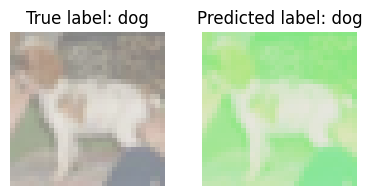

In [7]:
# Create a subplot with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(4, 2))

# Show the original image in the first subplot
ax1.imshow(image / 2 + 0.5)  # Assuming the image is scaled between 0 and 1
ax1.set_title(f"True label: {class_names[test_labels[i][0]]}")
ax1.axis('off')  # Hide the axis

# Show the LIME explanation in the second subplot
ax2.imshow(mark_boundaries(temp / 2 + 0.5, mask))
ax2.set_title(f"Predicted label: {class_names[exp.top_labels[0]]}")
ax2.axis('off')  # Hide the axis

# Display the figure
plt.tight_layout()
plt.show()